In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
import hybridlane as hqml
from collections import Counter
from pennylane.wires import Wires
from hybridlane.sa import ComputationalBasis, BasisSchema
from hybridlane.templates import StateTransferCVtoDV, StateTransferDVtoCV

print("Using state transfer templates from hybridlane")

Using state transfer templates from hybridlane


## 1. Draw the circuit

The `StateTransferCVtoDV` gate draws as a single block. We can also view the
decomposed version showing the V_j / W_j conditional displacements and the
basis transformation.

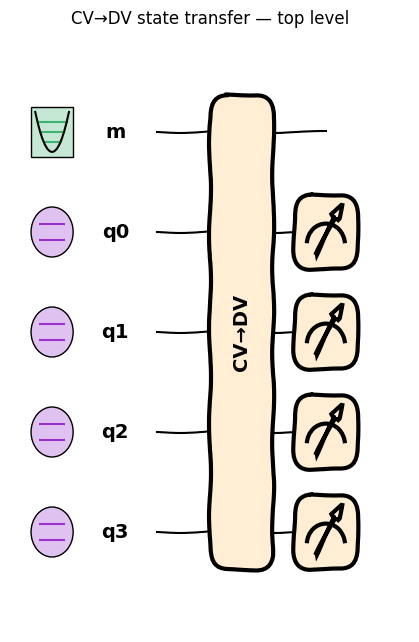

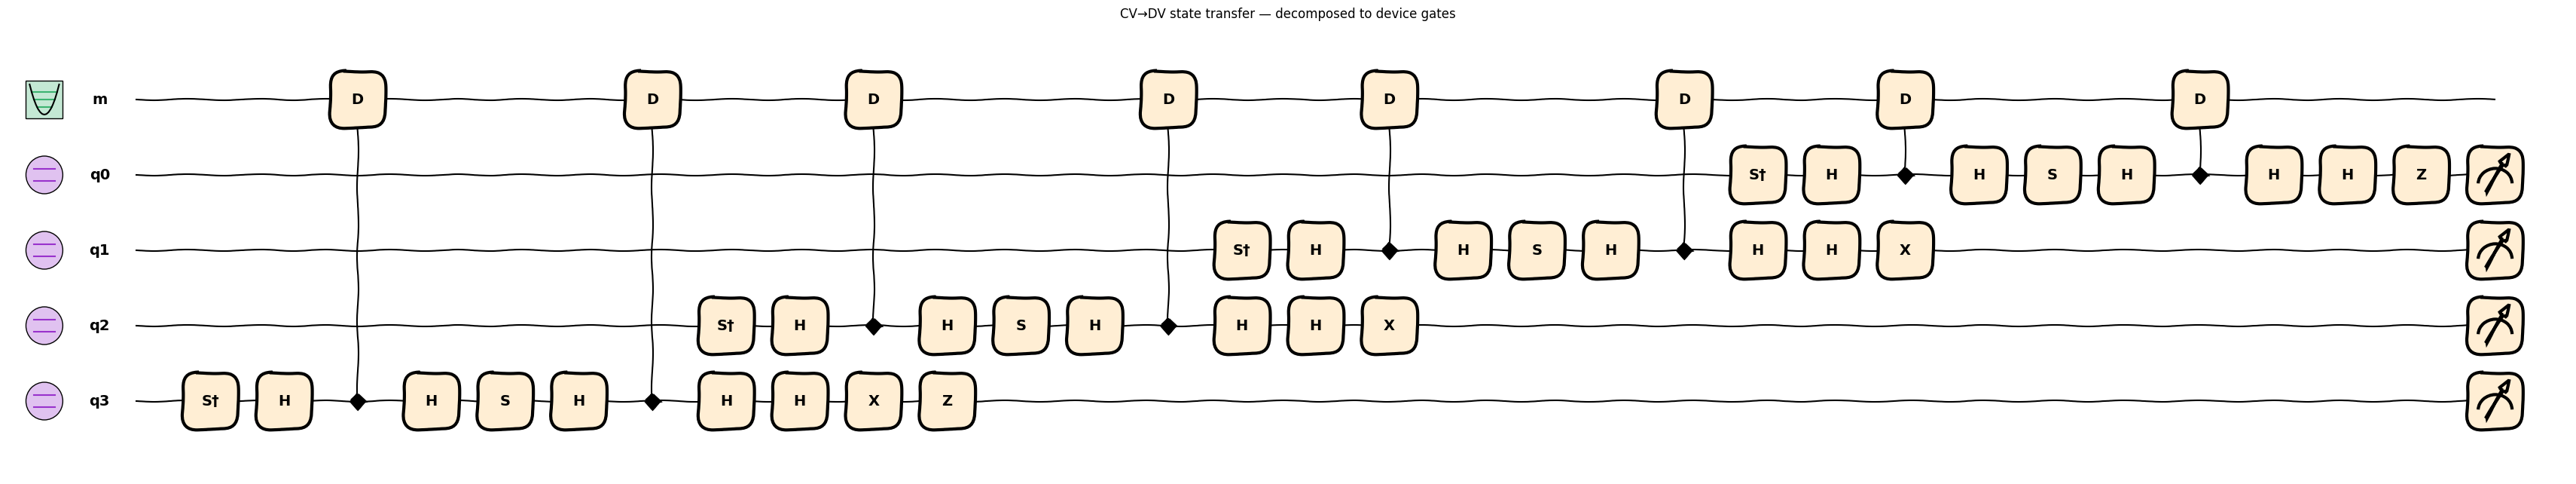

In [2]:
n_qubits = 4
lmbda = 0.29

def state_transfer_circuit(n_qubits, lmbda):
    """Apply state transfer and measure <Z> on each qubit."""
    wires = [f"q{i}" for i in range(n_qubits)] + ["m"]
    StateTransferCVtoDV(n_qubits, lmbda, wires=wires)
    return tuple(hqml.expval(qml.Z(f"q{i}")) for i in range(n_qubits))

# Top-level view: StateTransferCVtoDV as a single gate
fig, ax = hqml.draw_mpl(state_transfer_circuit, style="sketch")(n_qubits, lmbda)
plt.title("CV→DV state transfer — top level")
plt.show()

# Decomposed view: shows H, CD, S, X, Z gates
from functools import partial
from hybridlane.devices.bosonic_qiskit.gates import supported_operations as native_gates

dev = qml.device("bosonicqiskit.hybrid", max_fock_level=256)

@partial(qml.transforms.decompose, gate_set=native_gates)
@qml.qnode(dev)
def st_decomposed(n_qubits, lmbda):
    wires = [f"q{i}" for i in range(n_qubits)] + ["m"]
    StateTransferCVtoDV(n_qubits, lmbda, wires=wires)
    return tuple(hqml.expval(qml.Z(f"q{i}")) for i in range(n_qubits))

fig, ax = hqml.draw_mpl(st_decomposed, style="sketch")(n_qubits, lmbda)
plt.title("CV→DV state transfer — decomposed to device gates")
plt.show()

## 2. Run vacuum state transfer — expectation values

Transfer the vacuum state |0⟩ on the qumode to n qubits.
For vacuum input, the DV output should be |000⟩ (all zeros),
so we expect ⟨Z⟩ ≈ +1 on each qubit.

In [3]:
dev = qml.device("bosonicqiskit.hybrid", max_fock_level=256)

qnode_z = qml.QNode(state_transfer_circuit, dev)

n_qubits = 4
lmbda = 0.29

z_vals = qnode_z(n_qubits, lmbda)

print(f"CV→DV state transfer  (n_qubits={n_qubits}, λ={lmbda})")
print("=" * 50)
for i, z in enumerate(z_vals):
    print(f"  ⟨Z_q{i}⟩ = {float(z):.6f}")
print()

CV→DV state transfer  (n_qubits=4, λ=0.29)
  ⟨Z_q0⟩ = 0.000000
  ⟨Z_q1⟩ = -0.000000
  ⟨Z_q2⟩ = -0.000000
  ⟨Z_q3⟩ = -0.000000



## 3. Plot DV measurement distribution

Sample qubits and reconstruct the computational basis distribution.
For vacuum input, the distribution should peak at |000⟩.

Measurement counts:
  |1000⟩: 1110  (0.271)
  |0111⟩: 1103  (0.269)
  |1001⟩: 679  (0.166)
  |0110⟩: 594  (0.145)
  |0101⟩: 213  (0.052)
  |1010⟩: 192  (0.047)
  |0100⟩: 48  (0.012)
  |1011⟩: 39  (0.010)
  |1100⟩: 31  (0.008)
  |0011⟩: 24  (0.006)
  |0010⟩: 17  (0.004)
  |1111⟩: 11  (0.003)
  |1110⟩: 10  (0.002)
  |0000⟩: 10  (0.002)
  |0001⟩: 8  (0.002)
  |1101⟩: 7  (0.002)


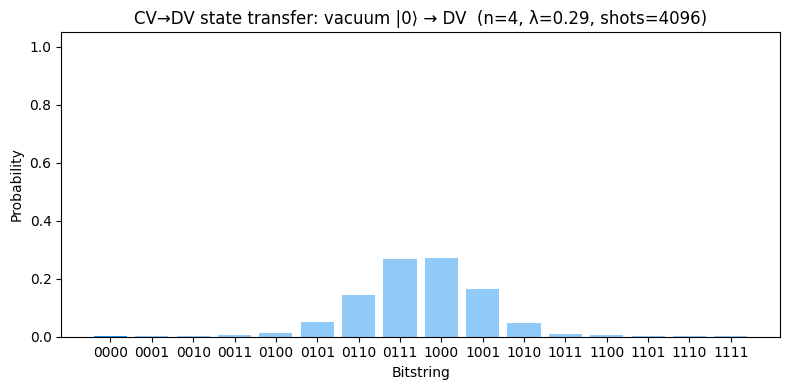

In [4]:
shots = 4096
n_qubits = 4
lmbda = 0.29

@qml.set_shots(shots)
@qml.qnode(dev)
def st_sample(n_qubits, lmbda):
    wires = [f"q{i}" for i in range(n_qubits)] + ["m"]
    qubit_wires = wires[:n_qubits]
    StateTransferCVtoDV(n_qubits, lmbda, wires=wires)
    schema = BasisSchema(
        {Wires(w): ComputationalBasis.Discrete for w in qubit_wires}
    )
    return hqml.sample(schema=schema)

result = st_sample(n_qubits, lmbda)

# Build bitstrings from basis_states (wire → array of per-shot values)
bitstrings = []
qubit_keys = [f"q{i}" for i in range(n_qubits)]
for shot_idx in range(shots):
    bs = "".join(str(result.basis_states[k][shot_idx]) for k in qubit_keys)
    bitstrings.append(bs)

counts = Counter(bitstrings)

# All possible bitstrings for n qubits
all_bs = [format(i, f"0{n_qubits}b") for i in range(2**n_qubits)]
probs = [counts.get(bs, 0) / shots for bs in all_bs]

print("Measurement counts:")
for bs in sorted(counts, key=counts.get, reverse=True):
    print(f"  |{bs}⟩: {counts[bs]}  ({counts[bs]/shots:.3f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2196F3" if bs == "0" * n_qubits else "#90CAF9" for bs in all_bs]
ax.bar(all_bs, probs, color=colors)
ax.set_xlabel("Bitstring")
ax.set_ylabel("Probability")
ax.set_title(f"CV→DV state transfer: vacuum |0⟩ → DV  (n={n_qubits}, λ={lmbda}, shots={shots})")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 4. Fock state inputs

To test with non-vacuum inputs, we prepare a state on the qumode *before* the
state transfer. `hqml.FockState(n, [ancilla, qumode])` prepares Fock state
|n⟩ using an ancilla qubit (which must be separate from the transfer qubits).

For Fock state |k⟩, the DV output should peak at the binary representation of k.


Fock |0⟩ transfer:
  |0111⟩: 1156  (0.282)
  |1000⟩: 1103  (0.269)
  |0110⟩: 627  (0.153)

Fock |1⟩ transfer:
  |1001⟩: 841  (0.205)
  |0110⟩: 819  (0.200)
  |0101⟩: 643  (0.157)

Fock |2⟩ transfer:
  |0101⟩: 718  (0.175)
  |1010⟩: 686  (0.167)
  |1011⟩: 554  (0.135)


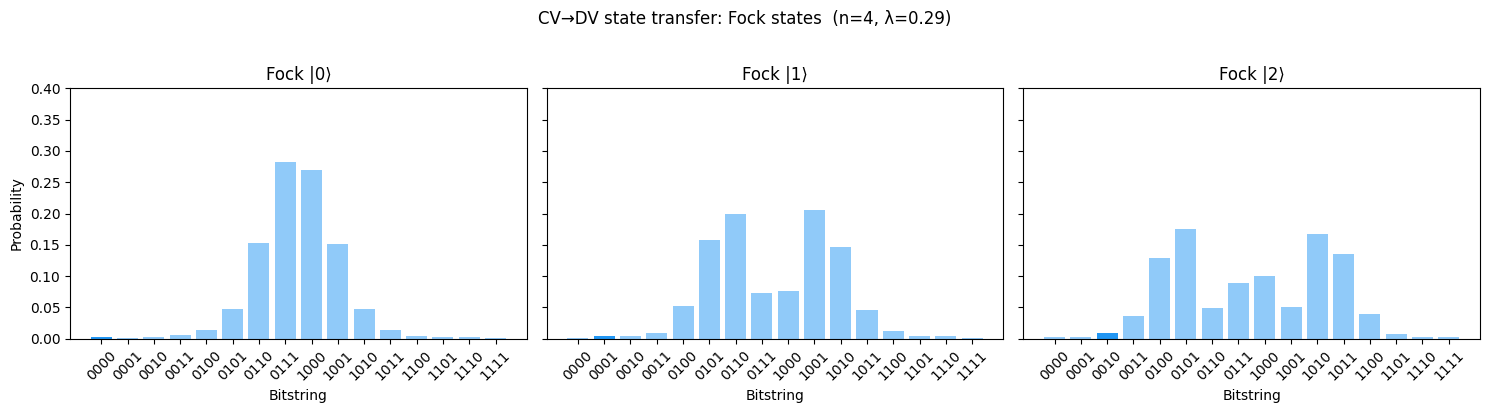

In [5]:
n_qubits = 4
lmbda = 0.29
shots = 4096

def run_fock_transfer(fock_n, n_qubits, lmbda, shots):
    """Prepare Fock state |fock_n⟩ on the qumode, then transfer to qubits."""
    dev = qml.device("bosonicqiskit.hybrid", max_fock_level=256)

    @qml.set_shots(shots)
    @qml.qnode(dev)
    def circuit(fock_n, n_qubits, lmbda):
        qubit_wires = [f"q{i}" for i in range(n_qubits)]
        m = "m"
        anc = "anc"  # separate ancilla for FockState

        # State prep: prepare |fock_n⟩ on the qumode using ancilla
        hqml.FockState(fock_n, [anc, m])

        # Transfer qumode state to qubits
        StateTransferCVtoDV(n_qubits, lmbda, wires=qubit_wires + [m])

        schema = BasisSchema(
            {Wires(w): ComputationalBasis.Discrete for w in qubit_wires}
        )
        return hqml.sample(schema=schema)

    result = circuit(fock_n, n_qubits, lmbda)

    qubit_keys = [f"q{i}" for i in range(n_qubits)]
    bitstrings = []
    for shot_idx in range(shots):
        bs = "".join(str(result.basis_states[k][shot_idx]) for k in qubit_keys)
        bitstrings.append(bs)

    return Counter(bitstrings)

# Test Fock states |0⟩, |1⟩, |2⟩
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
all_bs = [format(i, f"0{n_qubits}b") for i in range(2**n_qubits)]

for ax, fock_n in zip(axes, [0, 1, 2]):
    counts = run_fock_transfer(fock_n, n_qubits, lmbda, shots)
    probs = [counts.get(bs, 0) / shots for bs in all_bs]
    expected_bs = format(fock_n, f"0{n_qubits}b")

    colors = ["#2196F3" if bs == expected_bs else "#90CAF9" for bs in all_bs]
    ax.bar(all_bs, probs, color=colors)
    ax.set_xlabel("Bitstring")
    ax.set_title(f"Fock |{fock_n}⟩")
    ax.set_ylim(0, 0.4)
    ax.tick_params(axis="x", rotation=45)

    # Print top counts
    print(f"\nFock |{fock_n}⟩ transfer:")
    for bs in sorted(counts, key=counts.get, reverse=True)[:3]:
        print(f"  |{bs}⟩: {counts[bs]}  ({counts[bs]/shots:.3f})")

axes[0].set_ylabel("Probability")
fig.suptitle(f"CV→DV state transfer: Fock states  (n={n_qubits}, λ={lmbda})", y=1.02)
plt.tight_layout()
plt.show()

## 5. Compile to Qscout ion trap (Optional)

Compile the state transfer circuit for the Sandia Qscout ion trap backend.
This demonstrates:
- Transpiling to native Qscout gates (SDF, R, RZ, etc.)
- Visualizing the device-level circuit
- Exporting to Jaqal IR for hardware execution

In [6]:
qml.decomposition.enable_graph()

from hybridlane.devices.sandia_qscout import get_default_style, to_jaqal

draw_options = get_default_style()

n_qubits = 4
lmbda = 0.29

qscout_dev = qml.device("sandiaqscout.hybrid", optimize=False, n_qubits=n_qubits)
qscout_qnode = qml.set_shots(qml.QNode(state_transfer_circuit, qscout_dev), 1024)

### Top-level circuit view on Qscout

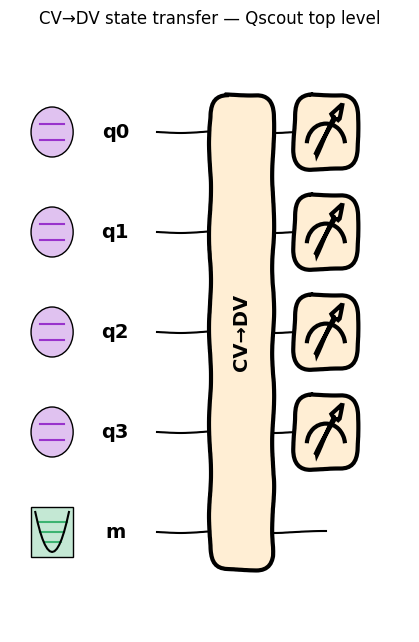

In [7]:
hqml.draw_mpl(qscout_qnode, level="top", style="sketch", **draw_options)(n_qubits, lmbda)
plt.title("CV→DV state transfer — Qscout top level")
plt.show()

### Device-level circuit — decomposed to native Qscout gates

Shows the full transpiled circuit with SDF (conditional displacement), rotation, and
single-qubit gates that would execute on the ion trap hardware.

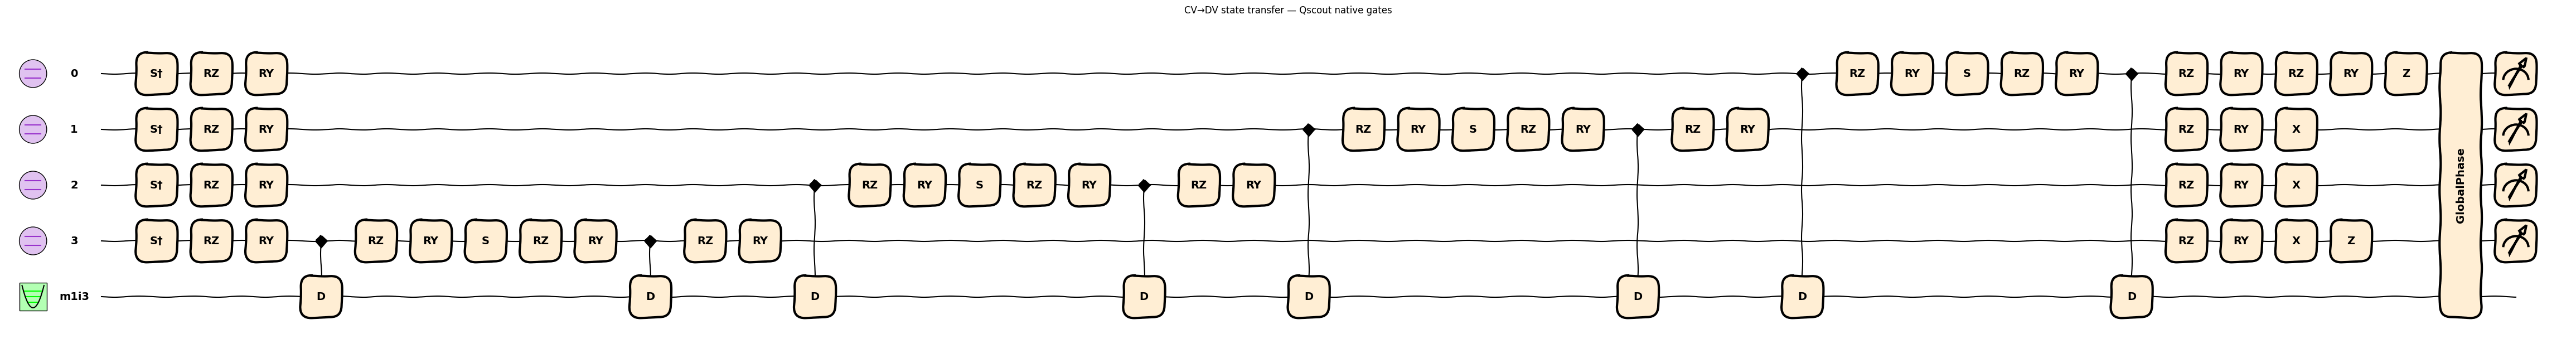

In [8]:

hqml.draw_mpl(qscout_qnode, level="device", style="sketch", **draw_options)(n_qubits, lmbda)
plt.title("CV→DV state transfer — Qscout native gates")
plt.show()

### Export to Jaqal IR

Generate the Jaqal intermediate representation that can be sent to the Qscout hardware.

In [9]:
# Generate Jaqal IR
ir = to_jaqal(qscout_qnode, level="device", precision=5)(n_qubits, lmbda)
print(ir)

from qscout.v1.std usepulses *

register q[4]

subcircuit 1024 {
	Szd q[3]
	Rz q[3] 3.1416
	Ry q[3] 1.5708
	zCD q[3] 1 3 0.00000000000000011726 1.9150
	Rz q[3] 3.1416
	Ry q[3] 1.5708
	Sz q[3]
	Rz q[3] 3.1416
	Ry q[3] 1.5708
	zCD q[3] 1 3 -0.20506 0.000000000000000025113
	Rz q[3] 3.1416
	Ry q[3] 1.5708
	Szd q[2]
	Rz q[2] 3.1416
	Ry q[2] 1.5708
	zCD q[2] 1 3 0.000000000000000058631 0.95752
	Rz q[2] 3.1416
	Ry q[2] 1.5708
	Sz q[2]
	Rz q[2] 3.1416
	Ry q[2] 1.5708
	zCD q[2] 1 3 -0.41012 0.000000000000000050225
	Rz q[2] 3.1416
	Ry q[2] 1.5708
	Szd q[1]
	Rz q[1] 3.1416
	Ry q[1] 1.5708
	zCD q[1] 1 3 0.000000000000000029316 0.47876
	Rz q[1] 3.1416
	Ry q[1] 1.5708
	Sz q[1]
	Rz q[1] 3.1416
	Ry q[1] 1.5708
	zCD q[1] 1 3 -0.82024 0.00000000000000010045
	Rz q[1] 3.1416
	Ry q[1] 1.5708
	Szd q[0]
	Rz q[0] 3.1416
	Ry q[0] 1.5708
	zCD q[0] 1 3 0.000000000000000014658 0.23938
	Rz q[0] 3.1416
	Ry q[0] 1.5708
	Sz q[0]
	Rz q[0] 3.1416
	Ry q[0] 1.5708
	zCD q[0] 1 3 1.6405 0.0
	Rz q[0] 3.1416
	Ry q[0] 1.5708
